<a href="https://colab.research.google.com/github/bajon1/Deep-learning-lab/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install openml optuna torch torchvision scikit-learn matplotlib numpy openml statsmodels

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
import optuna
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import KFold
from scipy import stats
import torch.nn.functional as F
from statsmodels.stats.contingency_tables import cochrans_q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Lab 4: MLP Architecture Optimization

# Task 1: Regression – network depth vs. width

#### Goal: Investigate the effect of the number of hidden layers and the number of neurons per layer on regression quality for a real dataset.

1. Load a real regression dataset from OpenML (e.g. a small/medium tabular dataset with one continuous target variable).
2. Split the data into training, validation, and test sets (e.g. 60/20/20 using train_test_split).
3. A regression MLP model in PyTorch as a class inheriting from nn.Module, using nn.ModuleList to store hidden layers — architecture: input → hidden_dim → … → hidden_dim → output (1 neuron for regression), with ReLU nonlinear activation after each hidden layer.
4. Train several architecture variants under the same training setup (MSELoss, Adam optimizer, fixed learning rate, fixed number of epochs, fixed batch size): variable depth at fixed width — n_hidden ∈ {1, 2, 4} with hidden_dim = 64; variable width at fixed depth — hidden_dim ∈ {16, 64, 256} with n_hidden = 2.
5. Save the best model checkpoint and compare validation MSE across all variants.
6. Compare test MSE across all variants.
Assignment: Implement an MLP with nn.ModuleList for a regression problem on a real OpenML dataset and compare the effect of depth and width on validation error. Explain why nn.ModuleList is used instead of a plain Python list.

In [3]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [79]:
from sklearn.datasets import fetch_california_housing

# Load California Housing — regression dataset
# 20,640 samples | 8 numeric features | target: median house value ($100k)
housing = fetch_california_housing(as_frame=True)

X = housing.data.values.astype(np.float32)
y = housing.target.values.astype(np.float32).reshape(-1, 1)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train = scaler_X.transform(X_train).astype("float32")
X_val = scaler_X.transform(X_val).astype("float32")
X_test = scaler_X.transform(X_test).astype("float32")
y_train = scaler_y.transform(y_train).astype("float32")
y_val = scaler_y.transform(y_val).astype("float32")
y_test = scaler_y.transform(y_test).astype("float32")

kfold = KFold(n_splits=5, shuffle=True)

print(f"Dataset:  California Housing")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}  →  {list(housing.feature_names)}")
print(f"Target:   {housing.target_names[0]}  |  min={y.min():.2f}  max={y.max():.2f}")

input_dim = housing.data.shape[1]

Dataset:  California Housing
Samples:  20640
Features: 8  →  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target:   MedHouseVal  |  min=0.15  max=5.00


In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_hidden):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)
        ])
        self.output = nn.Linear(hidden_dim, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input(x))
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
        logits = self.output(x)
        return logits

In [5]:
def train(model, X_train, X_val, y_train, y_val, batch_size=1024, epochs=50, lr=1e-3):
    best_val_loss = np.inf
    train_losses = []
    val_losses = []
    checkpoint = None

    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    model.to(device)
    criterion = nn.MSELoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True, pin_memory=(device == "cuda"))

    X_val_t = torch.tensor(X_val).to(device)
    y_val_t = torch.tensor(y_val).to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optim.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optim.step()
            train_loss += loss.item() * len(X_batch)

        train_losses.append(train_loss / len(X_train))

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
              best_val_loss = val_loss
              checkpoint = {
                  'model_state': model.state_dict(),
                  'optim_state': optim.state_dict(),
                  'epoch': epoch,
                  'best_val_loss': best_val_loss,
                  'train_losses': train_losses.copy(),
                  'val_losses': val_losses.copy()
              }

    torch.cuda.empty_cache()
    del model, optim

    return checkpoint

In [44]:
import os
os.makedirs("lab4-models", exist_ok=True)

# n_hidden ∈ {1, 2, 4} with hidden_dim = 64; variable width at fixed depth — hidden_dim ∈ {16, 64, 256} with n_hidden = 2.
input_dim = housing.data.shape[1]
n_hidden_list = [1, 2, 4]
hidden_dim_list = [16, 64, 256]

results = {}
for n_hidden in [1, 2, 4]:
    model = MLP(input_dim=input_dim, hidden_dim=64, n_hidden=n_hidden)
    checkpoint = train(model, batch_size=1024, epochs=100, lr=1e-3)
    key = f"depth={n_hidden}_width=64"
    results[key] = checkpoint
    torch.save(checkpoint, f"lab4-models/{key}.pt")
    print(f"{key} — best val loss: {checkpoint['best_val_loss']:.4f} (epoch {checkpoint['epoch']})")

print()

for hidden_dim in [16, 64, 256]:
    model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, n_hidden=2)
    checkpoint = train(model, batch_size=1024, epochs=100, lr=1e-3)
    key = f"depth=2_width={hidden_dim}"
    results[key] = checkpoint
    torch.save(checkpoint, f"lab4-models/{key}.pt")
    print(f"{key} — best val loss: {checkpoint['best_val_loss']:.4f} (epoch {checkpoint['epoch']})")

depth=1_width=64 — best val loss: 0.2251 (epoch 98)
depth=2_width=64 — best val loss: 0.2123 (epoch 96)
depth=4_width=64 — best val loss: 0.2180 (epoch 83)

depth=2_width=16 — best val loss: 0.2413 (epoch 98)
depth=2_width=64 — best val loss: 0.2198 (epoch 96)
depth=2_width=256 — best val loss: 0.2121 (epoch 78)


In [42]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
criterion = nn.MSELoss()

X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test).to(device)

print(f"{'Model':<25} {'Val MSE':>10} {'Test MSE':>10}")
print("-" * 47)

configs = [
    ("depth=1_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=1)),
    ("depth=2_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=2)),
    ("depth=4_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=4)),
    ("depth=2_width=16",  dict(input_dim=input_dim, hidden_dim=16,  n_hidden=2)),
    ("depth=2_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=2)),
    ("depth=2_width=256", dict(input_dim=input_dim, hidden_dim=256, n_hidden=2)),
]

for key, kwargs in configs:
    checkpoint = torch.load(f"lab4-models/{key}.pt", map_location=device)

    model = MLP(**kwargs).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()

    print(f"{key:<25} {checkpoint['best_val_loss']:>10.4f} {test_loss:>10.4f}")

Model                        Val MSE   Test MSE
-----------------------------------------------
depth=1_width=64              0.2402     0.2355
depth=2_width=64              0.2295     0.2199
depth=4_width=64              0.2221     0.2130
depth=2_width=16              0.2607     0.2554
depth=2_width=64              0.2295     0.2199
depth=2_width=256             0.2127     0.2069


In [ ]:
depths = [2, 4, 8, 16, 32, 64, 128]
widths = [16, 32, 64, 128, 256, 512, 1024]
results = np.zeros((len(depths), len(widths)))

for i, depth in enumerate(depths):
    for j, width in enumerate(widths):
            model = MLP(input_dim=input_dim, hidden_dim=width, n_hidden=depth)
            checkpoint = train(model, batch_size=1024, epochs=100, lr=1e-3)
            results[i, j] = checkpoint['best_val_loss']
            key = f"depth={depth}_width={width}"
            torch.save(checkpoint, f"lab4-models/{key}.pt")
            print(f"{key} — best val loss: {checkpoint['best_val_loss']:.4f}")

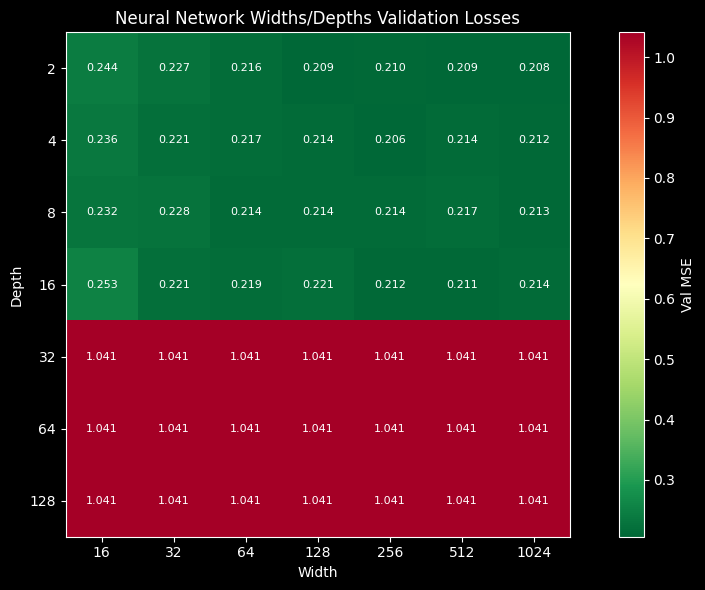

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(results, cmap="RdYlGn_r")

ax.set_xticks(range(len(widths)))
ax.set_xticklabels(widths)
ax.set_yticks(range(len(depths)))
ax.set_yticklabels(depths)
ax.set(xlabel="Width", ylabel="Depth", title="Neural Network Widths/Depths Validation Losses")

for i, depth in enumerate(depths):
    for j, width in enumerate(widths):
        ax.text(j, i, f"{results[i, j]:.3f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Val MSE")
plt.tight_layout()
plt.show()

# Task 2: Regression – automatic depth and width optimization

#### Goal: Use the Optuna library to select the optimal network depth and width.

1. For the data from Task 1, define an objective function for hyperparameter optimization using Optuna with 5-fold cross-validation.
2. Train five models with the optimal architecture (one per fold of the 5-fold cross-validation).
3. Run inference on the test set using an ensemble of the five trained models.

Assignment: Implement a function for automatic MLP architecture optimization using Optuna.

In [6]:
def objective(trial):
    n_hidden = trial.suggest_int('n_hidden', 1, 32)
    hidden_dim = trial.suggest_int('hidden_dim', 1, 256)
    epochs = trial.suggest_int('epochs', 10, 100)
    lr = trial.suggest_float('lr', 1e-5, 1e-1)

    kfold = KFold(n_splits=5, shuffle=True)
    val_losses = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
        X_train_f, X_val_f = X_train[train_idx], X_train[val_idx]
        y_train_f, y_val_f = y_train[train_idx], y_train[val_idx]

        model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, n_hidden=n_hidden)
        checkpoint = train(model, X_train_f, X_val_f, y_train_f, y_val_f, batch_size=1024, epochs=epochs, lr=lr)
        val_losses.append(checkpoint['best_val_loss'])

    return(np.mean(val_losses))

In [26]:
study = optuna.create_study(direction="minimize", study_name='lab4_2', storage="sqlite:///lab4-optuna.db", load_if_exists=True)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best trial — val loss: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-05-26 21:59:16,512] Using an existing study with name 'lab4_2' instead of creating a new one.
Best trial: 1. Best value: 0.848615:   1%|          | 1/100 [00:22<36:20, 22.03s/it]

[I 2026-05-26 21:59:38,541] Trial 1 finished with value: 0.8486150503158569 and parameters: {'n_hidden': 13, 'hidden_dim': 99, 'epochs': 81, 'lr': 0.04563779302183898}. Best is trial 1 with value: 0.8486150503158569.


Best trial: 1. Best value: 0.848615:   2%|▏         | 2/100 [00:31<24:11, 14.81s/it]

[I 2026-05-26 21:59:48,306] Trial 2 finished with value: 0.9998791217803955 and parameters: {'n_hidden': 28, 'hidden_dim': 62, 'epochs': 24, 'lr': 0.027862610018208823}. Best is trial 1 with value: 0.8486150503158569.


Best trial: 1. Best value: 0.848615:   3%|▎         | 3/100 [00:46<24:10, 14.95s/it]

...

[I 2026-05-26 22:25:42,158] Trial 98 finished with value: 0.20189979970455169 and parameters: {'n_hidden': 1, 'hidden_dim': 171, 'epochs': 98, 'lr': 0.006978429705769089}. Best is trial 84 with value: 0.1996581643819809.


Best trial: 99. Best value: 0.198081:  99%|█████████▉| 99/100 [26:39<00:14, 14.21s/it]

[I 2026-05-26 22:25:55,787] Trial 99 finished with value: 0.19808129966259003 and parameters: {'n_hidden': 1, 'hidden_dim': 168, 'epochs': 98, 'lr': 0.0073776036371962705}. Best is trial 99 with value: 0.19808129966259003.


Best trial: 99. Best value: 0.198081: 100%|██████████| 100/100 [26:43<00:00, 16.04s/it]

[I 2026-05-26 22:26:00,472] Trial 100 finished with value: 0.21198687553405762 and parameters: {'n_hidden': 2, 'hidden_dim': 166, 'epochs': 30, 'lr': 0.01352543724441516}. Best is trial 99 with value: 0.19808129966259003.
Best trial — val loss: 0.1981
Best params: {'n_hidden': 1, 'hidden_dim': 168, 'epochs': 98, 'lr': 0.0073776036371962705}


In [7]:
study = optuna.load_study(study_name="lab4_2", storage="sqlite:///lab4-optuna.db")

optuna_epochs = study.best_params['epochs']
optuna_lr = study.best_params['lr']

fold_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    X_train_f, X_val_f = X_train[train_idx], X_train[val_idx]
    y_train_f, y_val_f = y_train[train_idx], y_train[val_idx]

    optuna_model = MLP(input_dim, study.best_params['hidden_dim'], study.best_params['n_hidden'])
    checkpoint = train(optuna_model, X_train_f, X_val_f, y_train_f, y_val_f, batch_size=1024, epochs=optuna_epochs, lr=optuna_lr)
    fold_models.append(checkpoint)

In [88]:
def reg_median_response(models, X, y):

  preds = []

  for model in models:
    with torch.no_grad():
      model.eval()
      preds.append(model(X).cpu().numpy())

  ensemble_pred = np.median(np.stack(preds, axis=0))

  mse  = np.mean((ensemble_pred - y_np) ** 2)
  rmse = np.sqrt(mse)
  mae  = np.mean(np.abs(ensemble_pred - y_np))

  return print(f"MSE:  {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}")

def reg_mean_response(models, X, y):

  preds = []

  for model in models:
    with torch.no_grad():
      model.eval()
      preds.append(model(X).cpu().numpy())

  ensemble_pred = np.mean(np.stack(preds, axis=0))

  mse  = np.mean((ensemble_pred - y_np) ** 2)
  rmse = np.sqrt(mse)
  mae  = np.mean(np.abs(ensemble_pred - y_np))

  return print(f"MSE:  {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}")

In [90]:
X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test).to(device)
y_np = y_test_t.cpu().numpy()

models = []

for checkpoint in fold_models:
  model = MLP(input_dim, study.best_params['hidden_dim'], study.best_params['n_hidden']).to(device)
  model.load_state_dict(checkpoint['model_state'])

  models.append(model)

print("Median response ensemble: ")
reg_median_response(models, X_test_t, y_np)

print("\nMean response ensemble: ")
reg_mean_response(models, X_test_t, y_np)

Median response ensemble: 
MSE:  1.0237
RMSE: 1.0118
MAE: 0.7598

Mean response ensemble: 
MSE:  0.9884
RMSE: 0.9942
MAE: 0.7844


# Task 3: Multiclass classification – architecture and activation search

#### Goal: Optimize the MLP architecture for a multiclass classification task on a real dataset.

1. Select and load a multiclass classification dataset from OpenML (at least 3 classes, approximately 1,000–10,000 samples, moderate number of features).
2. Preprocessing: one-hot encode categorical features; standardize numerical features; split into train+validation and test sets (e.g. 80/20, stratified by class label).
3. An MLP in PyTorch using nn.ModuleList for hidden layers, parameterized by: number of hidden layers (n_hidden), hidden layer size (hidden_dim), and activation function (ReLU or Tanh).
4. Optimize the above hyperparameters using Optuna.
5. Extract the three best hyperparameter configurations from the optimization results.
6. For each of the three configurations: train five models using 5-fold cross-validation.
7. Evaluate all three configurations on the test set using CrossEntropyLoss and accuracy; save the results.

Assignment: Build and train the three most optimal MLP variants with nn.ModuleList for multiclass classification. Compare classification quality on the test set.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
from ucimlrepo import fetch_ucirepo

# Dry Bean Dataset - 13611 samples, 16 features, 7 classes
dry_bean = fetch_ucirepo(id=602)

X = dry_bean.data.features.values.astype("float32")
y = LabelEncoder().fit_transform(dry_bean.data.targets.values.ravel())

print(f"Dataset:  Dry Bean")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Classes:  {np.unique(dry_bean.data.targets.values).tolist()}")
print(f"Class counts: {np.bincount(y)}")

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_trainval)
X_trainval = scaler.transform(X_trainval).astype("float32")
X_test     = scaler.transform(X_test).astype("float32")

input_dim = X_trainval.shape[1]
n_classes = len(np.unique(y))

print(f"\nX_trainval: {X_trainval.shape}")
print(f"X_test:     {X_test.shape}")
print(f"n_classes:  {n_classes}")

Dataset:  Dry Bean
Samples:  13611
Features: 16
Classes:  ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Class counts: [1322  522 1630 3546 1928 2027 2636]

X_trainval: (10888, 16)
X_test:     (2723, 16)
n_classes:  7


# Task 4: Multi-label classification – independent output heads in ModuleList

#### Goal: Investigate the difference between a single shared output layer and independent per-label heads in a multi-label classification task.

1. Load a multi-label classification dataset from OpenML, e.g.:

```python
dataset = openml.datasets.get_dataset(312)
X, _, _, _ = dataset.get_data(target=None)
label_cols = ["Beach", "Sunset", "FallFoliage", "Field", "Mountain", "Urban"]
attr_cols = [col for col in X.columns if 'attr' in col]
y = X[label_cols].values.astype(np.float32)
X = X[attr_cols]
```

2. Data preparation: convert labels to a 0/1 matrix of shape [n_samples, n_labels]; split into training, validation, and test sets.
3. Baseline model (shared output): MLP with nn.ModuleList for the shared network body; one linear output layer nn.Linear(hidden_dim, n_labels); sigmoid activation on output, BCEWithLogitsLoss as the loss function.
4. Multi-head model (independent branches): same shared body as above; self.heads = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(n_labels)]); in the forward method, pass through the body, then through each head separately, and concatenate the results along the feature dimension.
5. Train both models with identical hyperparameters (same optimizer, number of epochs, batch size) and compare multi-label metrics — Hamming loss, micro-F1, macro-F1 — on the validation and test sets.

Assignment: Implement two MLP variants with nn.ModuleList for multi-label classification and compare whether the independent-heads architecture improves prediction quality over the shared output layer.

# Task 5: Fixed parameter budget – different network shapes

#### Goal: Investigate how network shape (depth vs. width) affects model quality when the total parameter count is held constant.

1. Choose one of the previous tasks (regression or multiclass classification) and use the same dataset.
2. Set an approximate parameter budget (e.g. ~50,000 parameters).
3. Design at least three MLP architectures that fit within the budget (±10%) but differ in shape: deep-narrow (more layers, smaller hidden_dim); shallow-wide (1–2 layers, large hidden_dim); "pyramid" (increasing or decreasing layer sizes, e.g. 32 → 64 → 32).
4. Compute and print the exact parameter count for each architecture.
5. Train each architecture under an identical setup (same number of epochs, batch size, optimizer, learning rate) and compare: training and validation loss curves; final validation results (MSE or accuracy).

Assignment: Build several MLP architectures with a similar parameter count and determine which network shape — deep-narrow, shallow-wide, or pyramid — achieves the best results.